## Loading Libraries and Initialization

In [1]:
import os, time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.optimize import minimize
from scipy.stats import multivariate_normal, norm
from scipy.special import logsumexp
from cvxopt import matrix, solvers

np.random.seed(42)

In [2]:
root_dir = "./PRNN_2026_A1_data"
plot_dir = "./Reporting-Plots"
df1_path = os.path.join(root_dir, "dataset_1.csv")
df2_path = os.path.join(root_dir, "dataset_2.csv")
df3_path = os.path.join(root_dir, "dataset_3.csv")
df4_path = os.path.join(root_dir, "dataset_4.csv")

## Phase 1: Bio-Optic Sensor Calibration (Dataset 1)

### 1.1 Gradient Descent vs. Closed Form

In [8]:
# Closed Form of Linear Regression
def ols_closed(X,y):
    y = y.reshape(-1)
    X = np.array(X)
    y = np.array(y)

    lhs = X.T @ X
    rhs = (X.T @ y)
    theta = np.linalg.inv(lhs) @ rhs

    return theta

# Gradient for Least Squares Linear Regression
def grad_ls(X,y,theta):
    n = X.shape[0]
    resid = (X @ theta) - y
    grad_ = (2/n) * (X.T @ resid)
    return grad_

# Vectorized Batch Gradient Descent
def batch_gradient_descent(X,y,grad, epsilon = 1e-6, lr = 0.01, max_iter = 10000):
    y = y.reshape(-1)
    theta = np.random.normal(size = X.shape[1])
    # theta = np.zeros(X.shape[1])
    iter_ = 0
    while iter_ < max_iter:
        grad_calc = grad(X,y, theta)
        if np.linalg.norm(grad_calc) < epsilon:
            break
        theta = theta - lr * grad_calc
        iter_+=1
    return theta

In [4]:
# Reading Dataset
df1 = pd.read_csv(df1_path)

X = np.array(df1.iloc[:,:-1].copy())
y = np.array(df1.iloc[:,-1].copy())

# Adding a Bias Column
ones_col = np.ones((X.shape[0],1))
X = np.hstack((X, ones_col),dtype = np.float32)

In [7]:
# Evaluation of Least Squares Regression
closed_soln = ols_closed(X,y)
batch_gd_soln = batch_gradient_descent(X,y,grad_ls, lr = 1e-4,epsilon = 1e-6)
norm_diff = np.linalg.norm(closed_soln-batch_gd_soln)

print("Closed Form Solution:", closed_soln)
print("Batch GD Solution:",batch_gd_soln)
print("Norm Difference:",norm_diff)

Closed Form Solution: [4.1929017  2.47190003]
Batch GD Solution: [4.19264971 2.34254517]
Norm Difference: 0.1293550998092464


### 1.2 Primal to Dual Translation

In [9]:
def train_svm(X, y):

    n_samples = X.shape[0]

    # Gram matrix
    K = X @ X.T
    H = np.outer(y, y) * K

    # Dual objective
    def objective(alpha):
        return 0.5 * alpha @ H @ alpha - np.sum(alpha)

    # Gradient of objective (important for speed)
    def gradient(alpha):
        return H @ alpha - np.ones(n_samples)

    # Equality constraint: Σ α_i y_i = 0
    def constraint(alpha):
        return np.dot(alpha, y)

    bounds = [(0, None) for _ in range(n_samples)]

    constraints = {'type': 'eq', 'fun': constraint}

    alpha0 = np.zeros(n_samples)

    result = minimize(
        objective,
        alpha0,
        jac=gradient,
        method='SLSQP',
        bounds=bounds,
        constraints=constraints,
        options={
            'maxiter': 300,   # ensures finite execution
            'ftol': 1e-6,
            'disp': True
        }
    )

    alpha = result.x

    # Weight vector
    w = np.sum((alpha * y)[:, None] * X, axis=0)

    # Support vectors
    sv = alpha > 1e-5
    sv_indices = np.where(sv)[0]

    X_sv = X[sv]
    y_sv = y[sv]

    # Bias
    b = np.mean(y_sv - X_sv @ w)

    return w, b, alpha, sv_indices

In [10]:
def visualize_dataset(X, y, sv_indices):
    plt.figure(figsize=(6,6))
    plt.scatter(X[y==1,0], X[y==1,1], color='blue', label='Class +1', alpha = 0.1)
    plt.scatter(X[y==-1,0], X[y==-1,1], color='red', label='Class -1', alpha = 0.1)

    plt.scatter(X[sv_indices,0],
                X[sv_indices,1],
                facecolors='none',
                edgecolors='black',
                s=120,
                label='Support Vectors')

    plt.xlabel("Feature 1")
    plt.ylabel("Feature 2")
    plt.title("Dataset 1 Visualization")
    plt.legend()
    plt.grid(True)

    plt.show()

In [13]:
# Solve the Hard-Margin SVM Problem for a subset of the data.
df1 = pd.read_csv(df1_path)
subset = 512

X = df1.iloc[:, :-1].values
y = df1.iloc[:, -1].values
idx = np.random.choice(len(X), subset, replace=False)
# Convert to binary classification using median
y_med = np.median(y)
y = np.where(y >= y_med, 1, -1)
# Taking only the subset of data
X_sub = X[idx]
y_sub = y[idx]

w, b, alpha, sv_indices = train_svm(X_sub, y_sub)

print("Number of Support Vector Indices:", len(sv_indices))

Iteration limit reached    (Exit mode 9)
            Current function value: -2048430570.6952314
            Iterations: 300
            Function evaluations: 356
            Gradient evaluations: 299
Number of Support Vector Indices: 218


## Phase 2: Oncology Array (Dataset 2)

### 2.3 The Singularity Trap

In [14]:
class StandardScaler:
    def __init__(self):
        self.mean_ = None
        self.std_dev_ = None

    def fit(self, X):
        X = np.asarray(X)
        if X.ndim != 2:
            raise ValueError("Input must be a 2D array")

        self.mean_ = np.mean(X, axis=0)
        std = np.std(X, axis=0)
        # avoid division by zero
        self.std_dev_ = np.where(std == 0, 1.0, std)
        return self

    def transform(self, X):
        if self.mean_ is None or self.std_dev_ is None:
            raise RuntimeError("Scaler must be fitted before transform")
        X = np.asarray(X)
        if X.shape[1] != self.mean_.shape[0]:
            raise ValueError("Mismatch between fit and transform dimensions")

        return (X - self.mean_) / self.std_dev_

    def fit_transform(self, X):
        self.fit(X)
        return self.transform(X)

In [15]:
# Gradient Function for L2 Regularization
def grad_l2(X,y,theta, lambda_):
    n = X.shape[0]
    resid = (X @ theta) - y
    
    theta_ = theta.copy()
    theta_[-1] = 0 # Bias should not be updated
    
    grad_ = (2/n) * (X.T @ resid) + 2 * lambda_ * theta_
    return grad_

# Batch Gradient Descent (Same function as before)
def batch_gradient_descent_l2(X,y,grad, lambda_, epsilon = 1e-6, lr = 0.01, max_iter = 500):
    y = y.reshape(-1)
    theta = np.random.normal(size = X.shape[1])
    # theta = np.zeros(X.shape[1])
    iter_ = 0
    while iter_ < max_iter:
        grad_calc = grad(X,y, theta, lambda_)
        if np.linalg.norm(grad_calc) < epsilon:
            break
        theta = theta - lr * grad_calc
        iter_+=1
    return theta

In [16]:
def run_ridge_condition_analysis(X, lambdas):
    # Center the feature matrix
    X = X - np.mean(X, axis=0)
    XTX = X.T @ X
    D = X.shape[1]
    condition_numbers = []
    I = np.eye(D)
    for lam in lambdas:
        matrix_to_invert = XTX + lam * I
        cond_num = np.linalg.cond(matrix_to_invert)
        condition_numbers.append(cond_num)

    return np.array(condition_numbers)


def plot_condition_number(lambda_values, cond_numbers, file_path=None):
    log_lambda = np.log10(lambda_values)
    plt.figure(figsize=(8,5))
    plt.plot(log_lambda, cond_numbers, linewidth=2)

    plt.xlabel("log10(lambda)", fontsize=12)
    plt.ylabel("Condition Number", fontsize=12)
    plt.title("Condition Number vs Regularization Strength (Ridge)", fontsize=14)

    plt.yscale("log")
    plt.grid(True, linestyle="--", alpha=0.6)

    plt.tight_layout()

    if file_path is not None:
        plt.savefig(file_path, dpi=300)

    plt.show()

In [18]:
# Reading Dataset
df2 = pd.read_csv(df2_path)

X = np.array(df2.iloc[:,:-1].copy())
y = np.array(df2.iloc[:,-1].copy())
X = X - np.mean(X, axis=0) # Centering the Data

# The L2-Regularization runs without any error. 
params_ = batch_gradient_descent_l2(X,y,grad_l2, lambda_ = 0.1)

# The condition number for X.T X is very high.
# This makes the matrix highly unstable.
print("Condition Number of X.T @ X:",np.linalg.cond(X.T @ X))

Condition Number of X.T @ X: 1.2738689670411518e+19


Highest condition number: 956596705.820896


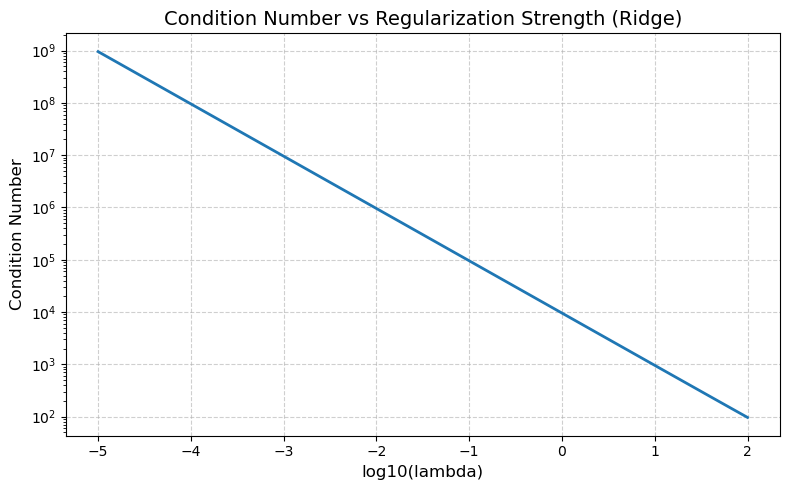

In [19]:
# Reading Dataset
df2 = pd.read_csv(df2_path)

X = np.array(df2.iloc[:,:-1].copy())
y = np.array(df2.iloc[:,-1].copy())

lambdas_ridge = np.logspace(-5, 2, 50)
condition_numbers = run_ridge_condition_analysis(X, lambdas_ridge)

# Plotting Condition Number of (X^TX + Lambda I)
file_name = "2_3_Condition.png"
print("Highest condition number:", condition_numbers[0])
plot_condition_number(lambdas_ridge, condition_numbers, file_path = file_name)

### 2.4 Lasso Sparsity

In [20]:
# Soft-Thresholding Function
def soft_threshold(rho, lambda_):
    if rho > lambda_:
        return rho - lambda_
    elif rho < -lambda_:
        return rho + lambda_
    else:
        return 0

# LASSO with Coordinate Descent
def coordinate_descent(X,y,lambda_, tol = 1e-4, max_iter = 10**3):
    N, num_feat = X.shape
    y = y.reshape(-1)
    
    theta_old = np.zeros(num_feat)
    theta_new = None
    iter_ = 0
    feature_norms = np.sum(X**2, axis = 0) # Pre-computation for Norm
    bias = num_feat -1  # Last feature is bias every-time.
    resid = y - X @ theta_old # Initializing the residual
    
    while iter_ < max_iter:
        theta_new = theta_old.copy()
        
        for feat in range(num_feat): 
            if feature_norms[feat] < 1e-8:
                continue
                
            X_j = X[:,feat]
            partial_resid = resid + theta_old[feat] * X_j
            rho = X_j.T @ partial_resid
            # Handling bias term in regularization.
            if feat == bias:
                w_new = rho/feature_norms[feat]
            else:
                w_new = soft_threshold(rho, lambda_)/feature_norms[feat]
            
            # Need to update residual based on the new parameter value.
            delta =  w_new - theta_old[feat]
            theta_old[feat] = w_new
            resid = resid - X_j * delta
            
        if np.linalg.norm(theta_old -  theta_new) <= tol:
            break   
        iter_+=1

    return theta_old   

In [21]:
# Run LASSO for different values of Lambda and check the sparsity.
def run_lasso_path(X, y, lambda_values):
    num_features = X.shape[1]
    weights = []
    sparsity = []

    for lam in lambda_values:
        theta = coordinate_descent(X, y, lam)
        weights.append(theta)
        zero_fraction = np.sum(np.abs(theta[:-1]) < 1e-6) / (num_features - 1)
        sparsity.append(zero_fraction)

    weights = np.array(weights)
    return weights, sparsity


def plot_regularization_path(lambda_values, weights, save = False, file_path = None):
    log_lambda = np.log10(lambda_values)
    plt.figure(figsize=(10,6))

    for j in range(weights.shape[1]-1):  # exclude bias
        plt.plot(log_lambda, weights[:, j], linewidth=1)

    plt.xlabel("log10(lambda)", fontsize=12)
    plt.ylabel("Weight Value", fontsize=12)
    plt.title("Lasso Regularization Path", fontsize=14)
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.tight_layout()

    if save:
        if file_path is None:
            raise ValueError("No File path provided")
        plt.savefig(file_path, dpi = 300)     
    plt.show()

In [22]:
# Reading Dataset
df2 = pd.read_csv(df2_path)

X = np.array(df2.iloc[:,:-1].copy())
y = np.array(df2.iloc[:,-1].copy())

# Adding a Bias Column
ones_col = np.ones((X.shape[0],1))
X = np.hstack((X, ones_col),dtype = np.float32)

In [23]:
start, stop, num_points = -5, 2, 50
lambda_values = np.logspace(start, stop, num_points)
weights, sparsity = run_lasso_path(X,y,lambda_values)

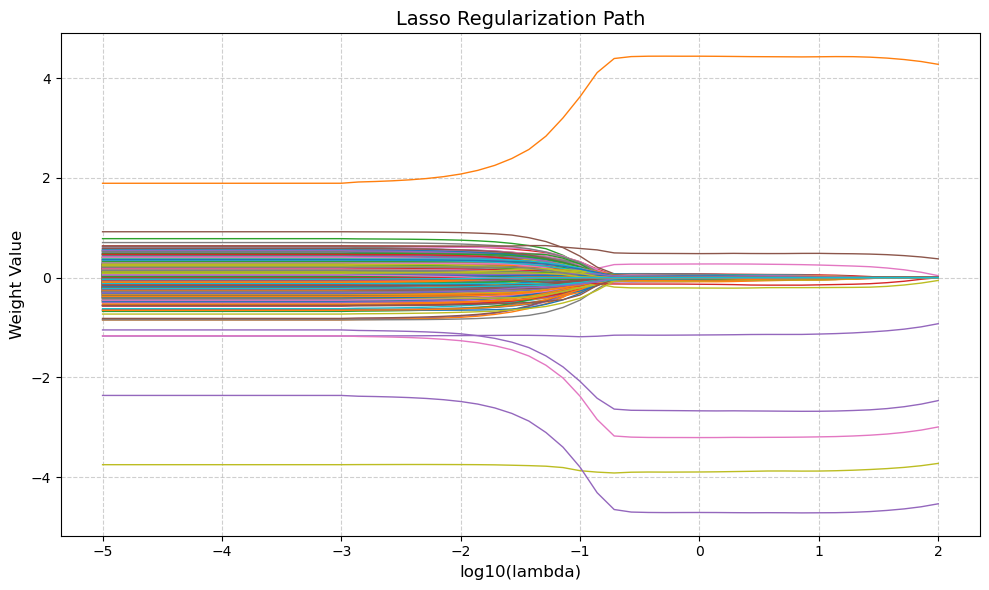

In [24]:
file_name = "2_4_Path.png"
file_path = os.path.join(plot_dir, file_name)

plot_regularization_path(lambda_values,weights,save = True, file_path = file_path)

In [25]:
# Printing the value of Regularization Coefficient that gives 50% sparsity.
sparsity_index = np.argmin(abs(np.array(sparsity)-0.5))

num_features = X.shape[1]
lam = lambda_values[sparsity_index]
theta = coordinate_descent(X, y, lam)
zero_fraction = np.sum(np.abs(theta[:-1]) < 1e-6) / (num_features - 1)
print(f"The value of lambda that gives 50% sparsity is: {lam:.5f}")
print("Sparsity:",zero_fraction*100,"%")

The value of lambda that gives 50% sparsity is: 0.37276
Sparsity: 50.6 %


## Phase 3: High-Frequency ICU Telemetry (Dataset 3)

### 3.5 Vectorized Logistic Regression

In [26]:
class StandardScaler:
    def __init__(self):
        self.mean_ = None
        self.std_dev_ = None

    def fit(self, X):
        X = np.asarray(X)
        if X.ndim != 2:
            raise ValueError("Input must be a 2D array")

        self.mean_ = np.mean(X, axis=0)
        std = np.std(X, axis=0)
        # avoid division by zero
        self.std_dev_ = np.where(std == 0, 1.0, std)
        return self

    def transform(self, X):
        if self.mean_ is None or self.std_dev_ is None:
            raise RuntimeError("Scaler must be fitted before transform")
        X = np.asarray(X)
        if X.shape[1] != self.mean_.shape[0]:
            raise ValueError("Mismatch between fit and transform dimensions")

        return (X - self.mean_) / self.std_dev_

    def fit_transform(self, X):
        self.fit(X)
        return self.transform(X)

In [21]:
def sigmoid(x):
    x = np.asarray(x)
    out = np.empty_like(x, dtype=float)

    pos_mask = x >= 0
    neg_mask = ~pos_mask

    out[pos_mask] = 1 / (1 + np.exp(-x[pos_mask]))
    exp_x = np.exp(x[neg_mask])
    out[neg_mask] = exp_x / (1 + exp_x)
    return out

def grad_l2_logistic(X, y, theta, lambda_=0):
    n = X.shape[0]
    prob = sigmoid(X @ theta)
    resid = prob - y

    theta_reg = theta.copy()
    theta_reg[-1] = 0   # do not regularize bias
    grad = (1/n) * (X.T @ resid) + 2 * lambda_ * theta_reg
    return grad

def logistic_loss_l2(X, y, theta, lambda_=0):
    n = X.shape[0]
    p = sigmoid(X @ theta)

    eps = 1e-12
    p = np.clip(p, eps, 1 - eps)

    loss = -(1/n) * np.sum(y*np.log(p) + (1-y)*np.log(1-p))

    # No regularization for bias term
    theta_reg = theta.copy()
    theta_reg[-1] = 0
    loss += lambda_ * np.sum(theta_reg**2)
    return loss

def batch_gd_logistic_l2(X, y, grad, lambda_=0, lr=0.01, max_iter=500, epsilon=1e-6):
    y = y.reshape(-1)
    theta = np.zeros(X.shape[1]) 
    loss_history = []

    prev_loss = float("inf")
    
    for i in range(max_iter):
        
        loss = logistic_loss_l2(X, y, theta, lambda_)
        loss_history.append(loss)
        grad_calc = grad(X, y, theta, lambda_)
        
        if abs(prev_loss - loss) < epsilon: # Early Stopping
                return loss_history,theta

        theta = theta - lr * grad_calc
        prev_grad = grad_calc

    return loss_history, theta

In [28]:
def plot_learning_curves(loss_small_lr, loss_large_lr, lr_stable, lr_large, file_path=None):

    fig, axes = plt.subplots(1, 2, figsize=(12,5))

    # Stable learning rate subplot
    axes[0].plot(loss_small_lr, linewidth=2, color='tab:blue')
    axes[0].set_title(f"Stable Learning Rate (η = {lr_stable})")
    axes[0].set_xlabel("Iteration")
    axes[0].set_ylabel("Logistic Loss")
    axes[0].set_xlim(-1,200)
    axes[0].set_ylim(0,3)
    axes[0].grid(True, linestyle="--", alpha=0.6)

    # Large learning rate subplot
    axes[1].plot(loss_large_lr, linewidth=2, color='tab:orange')
    axes[1].set_title(f"Large LR (η = {lr_large}) — Violates Lipschitz")
    axes[1].set_xlabel("Iteration")
    axes[1].set_ylabel("Logistic Loss")
    axes[1].set_xlim(0,200)
    axes[1].set_ylim(0,3)
    axes[1].grid(True, linestyle="--", alpha=0.6)

    fig.suptitle("Learning Curves for Logistic Regression", fontsize=14)

    plt.tight_layout()

    if file_path:
        plt.savefig(file_path, dpi=300)

    plt.show()

In [29]:
# Reading Dataset
df3 = pd.read_csv(df3_path)
df3_filtered = df3[df3['label'].isin([2,1])].copy()
df3_filtered.loc[df3_filtered['label'] == 2, 'label'] = 0
df3_filtered.loc[df3_filtered['label'] == 1, 'label'] = 1


X = np.array(df3_filtered.iloc[:,:-1].copy())
y = np.array(df3_filtered.iloc[:,-1].copy())

std_scaler = StandardScaler()
std_scaler.fit(X)
X_std = std_scaler.transform(X)

# Adding a Bias Column
ones_col = np.ones((X_std.shape[0],1))
X_std = np.hstack((X_std, ones_col),dtype = np.float32)

In [30]:
lambda_ = 0.01

lr_stable = 0.01
lr_large  = 34.0 # violates Lipschitz but does not instantly saturate


loss_small_lr, theta1 = batch_gd_logistic_l2(X_std, y, grad_l2_logistic, lambda_, lr_stable, max_iter = 1000)
loss_large_lr, theta2 = batch_gd_logistic_l2(X_std, y, grad_l2_logistic, lambda_, lr_large, max_iter = 1000)

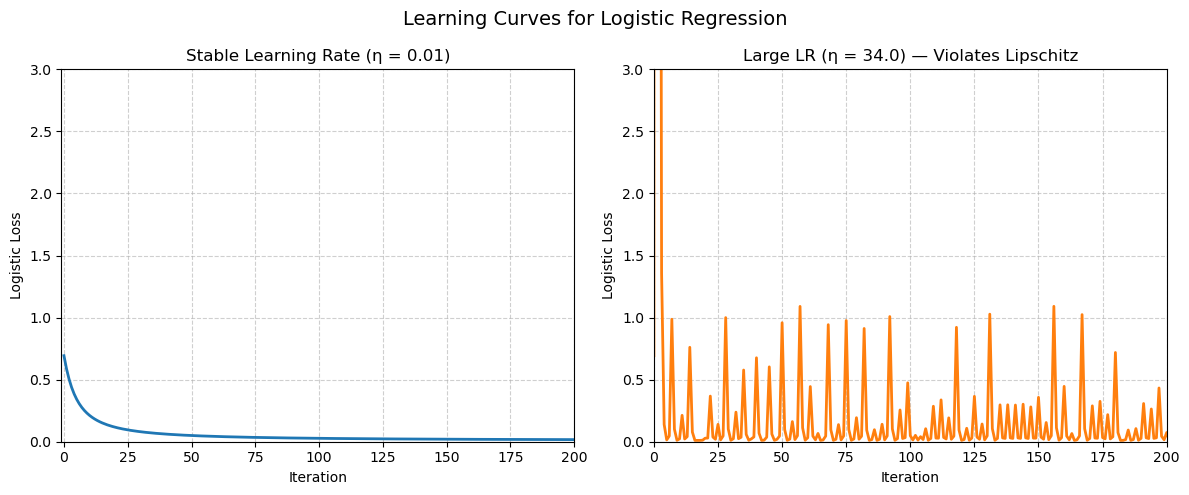

In [31]:
file_name = "3_5_learning_curve.png"
file_path = os.path.join(plot_dir, file_name)

plot_learning_curves(loss_small_lr, loss_large_lr, lr_stable, lr_large, file_path = file_path)

### 3.6 GMM Initialization & The E-Step

In [4]:
# Log Likelihood Function
def compute_log_likelihood(X, mu, Sigma, pi):

    N = X.shape[0]
    K = len(pi)

    log_probs = np.zeros((N, K))

    for k in range(K):
        log_probs[:, k] = np.log(pi[k]) + multivariate_normal.logpdf(
            X, mean=mu[k], cov=Sigma[k], allow_singular=True
        )

    return np.sum(logsumexp(log_probs, axis=1))

# Execute one EM iteration
def exec_em_once(X, K=4):

    N, D = X.shape

    # -------- Initialization --------
    indices = np.random.choice(N, K, replace=False)
    mu = X[indices] # Picks 4 random data points. Those become means.

    sigma2 = np.var(X)
    Sigma = np.array([sigma2 * np.eye(D) for _ in range(K)]) # Covariance Matrix taken as diagonal.

    pi = np.ones(K) / K   # Initial probability taken as uniform distribution.


    # -------- Initial Log Likelihood --------
    initial_ll = compute_log_likelihood(X, mu, Sigma, pi)
    print(f"Initial Log Likelihood: {initial_ll:.4f}")


    # -------- E STEP (log space) --------
    log_gamma = np.zeros((N, K))

    for k in range(K):
        log_gamma[:, k] = np.log(pi[k]) + multivariate_normal.logpdf(X, mean=mu[k], cov=Sigma[k], allow_singular=True)

    log_norm = logsumexp(log_gamma, axis=1, keepdims=True)
    gamma = np.exp(log_gamma - log_norm)


    # -------- M STEP --------
    Nk = gamma.sum(axis=0)
    mu = (gamma.T @ X) / Nk[:, None]  # Update means
    Sigma_new = []  # Update spherical covariance

    for k in range(K):
        diff = X - mu[k]
        var = np.sum(gamma[:, k] * np.sum(diff**2, axis=1)) / (Nk[k] * D)
        Sigma_new.append(var * np.eye(D))

    Sigma = np.array(Sigma_new)

    # Update mixture weights
    pi = Nk / N
    
    # -------- Log Likelihood After Iteration --------
    final_ll = compute_log_likelihood(X, mu, Sigma, pi)

    print(f"Log Likelihood After One EM Iteration: {final_ll:.4f}")
    print(f"Differnce in Log Likelihood: {(final_ll - initial_ll):.4f}")

In [3]:
df3 = pd.read_csv(df3_path)

X = np.array(df3.iloc[:,:-1].copy())
y = np.array(df3.iloc[:,-1].copy())

# exec_em_once(X)

In [20]:
indices = np.random.choice(N, K, replace=False)
mu = X[indices] # Picks 4 random data points. Those become means.

sigma2 = np.var(X)
Sigma = np.array([sigma2 * np.eye(D) for _ in range(K)]) # Covariance Matrix taken as diagonal.
print(Sigma.shape)
print(mu.shape)
multivariate_normal.logpdf(X, mean=mu[0], cov=Sigma[0], allow_singular=True).shape

(4, 50, 50)
(4, 50)


(20000,)

In [13]:
K = 4
N, D = X.shape
print(X.shape)
# -------- Initialization --------
indices = np.random.choice(N, K, replace=False)
sigma2 = np.var(X)
np.array([sigma2 * np.eye(D) for _ in range(K)])[1]

(20000, 50)


array([[29.4766935,  0.       ,  0.       , ...,  0.       ,  0.       ,
         0.       ],
       [ 0.       , 29.4766935,  0.       , ...,  0.       ,  0.       ,
         0.       ],
       [ 0.       ,  0.       , 29.4766935, ...,  0.       ,  0.       ,
         0.       ],
       ...,
       [ 0.       ,  0.       ,  0.       , ..., 29.4766935,  0.       ,
         0.       ],
       [ 0.       ,  0.       ,  0.       , ...,  0.       , 29.4766935,
         0.       ],
       [ 0.       ,  0.       ,  0.       , ...,  0.       ,  0.       ,
        29.4766935]])

### 3.7 EM Convergence & Crashes

In [34]:
def run_gmm_em(X, K, max_iters=50, reg=1e-6):

    N, D = X.shape

    # Initialization
    indices = np.random.choice(N, K, replace=False)
    mu = X[indices]

    Sigma = np.array([np.cov(X.T) + reg * np.eye(D) for _ in range(K)])
    pi = np.ones(K) / K

    log_likelihoods = []

    for it in range(max_iters):
        
        # E STEP
        log_gamma = np.zeros((N, K))

        for k in range(K):
            log_gamma[:, k] = (
                np.log(pi[k]) +
                multivariate_normal.logpdf(X, mu[k], Sigma[k], allow_singular=True))

        log_norm = logsumexp(log_gamma, axis=1, keepdims=True)
        gamma = np.exp(log_gamma - log_norm)

        
        # M STEP
        Nk = gamma.sum(axis=0)
        mu = (gamma.T @ X) / Nk[:, None]
        Sigma_new = []

        for k in range(K):
            diff = X - mu[k]
            cov = (gamma[:, k][:, None] * diff).T @ diff / Nk[k]

            # Regularization prevents collapse
            cov += reg * np.eye(D)

            Sigma_new.append(cov)

        Sigma = np.array(Sigma_new)

        pi = Nk / N

        # log likelihood
        ll = compute_log_likelihood(X, mu, Sigma, pi)
        log_likelihoods.append(ll)

    return mu, Sigma, pi, log_likelihoods

In [35]:
def run_gmm_with_forced_crash(X, K=4, crash_iter=5):
    N, D = X.shape
    indices = np.random.choice(N, K, replace=False)
    mu = X[indices]

    Sigma = np.array([np.cov(X.T) for _ in range(K)])
    pi = np.ones(K) / K

    for it in range(10):
        if it == crash_iter:
            print("\nForcing covariance collapse...\n")
            Sigma[0] = np.zeros((D, D))   # singular covariance
        gamma = np.zeros((N, K))

        for k in range(K):
            gamma[:, k] = pi[k] * multivariate_normal.pdf(X,mean=mu[k], cov=Sigma[k])

        gamma = gamma / gamma.sum(axis=1, keepdims=True)

        Nk = gamma.sum(axis=0)
        mu = (gamma.T @ X) / Nk[:, None]

        for k in range(K):

            diff = X - mu[k]
            Sigma[k] = (gamma[:, k][:, None] * diff).T @ diff / Nk[k]

        pi = Nk / N

In [36]:
def plot_log_likelihood_curves(results, save_path = None):
    plt.figure(figsize=(8,5))
    for K, ll in results.items():
        plt.plot(ll, label=f"K = {K}")

    plt.xlabel("Iteration")
    plt.ylabel("Log Likelihood")
    plt.title("EM Convergence for GMM")
    plt.legend()
    plt.grid(True)

    if save_path is not None:
        plt.savefig(save_path, dpi = 300)  
    plt.show()

In [37]:
df3 = pd.read_csv(df3_path)

X = np.array(df3.iloc[:,:-1].copy())
y = np.array(df3.iloc[:,-1].copy())

In [38]:
print("\nRunning crash experiment...")
# run_gmm_with_forced_crash(X, K=4)


Running crash experiment...

Forcing covariance collapse...



LinAlgError: When `allow_singular is False`, the input matrix must be symmetric positive definite.


Running EM for K = 2

Running EM for K = 4

Running EM for K = 6


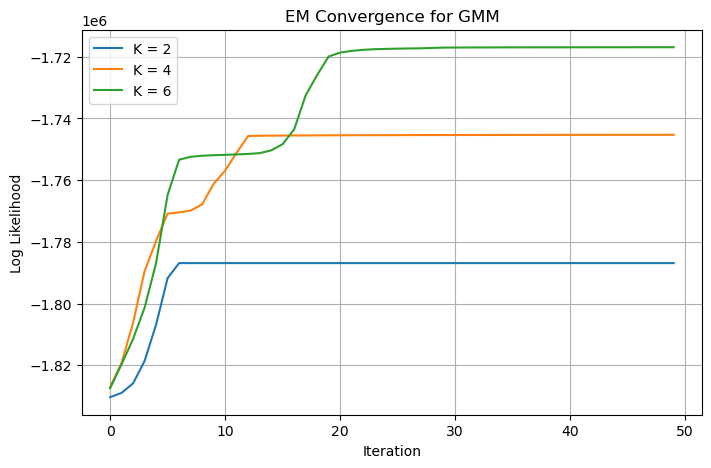

In [39]:
results = {}
file_name = "3_7_Convergence.png"
file_path = os.path.join(plot_dir, file_name)

for K in [2, 4, 6]:
    print(f"\nRunning EM for K = {K}")
    mu, Sigma, pi, ll = run_gmm_em(X, K)
    results[K] = ll


plot_log_likelihood_curves(results, file_path)

### 3.8 Decision Boundaries

In [40]:
def compute_decision_grid(mu, Sigma, pi, grid_res=300):
    K = len(pi)
    x_min, x_max = mu[:,0].min()-3, mu[:,0].max()+3
    y_min, y_max = mu[:,1].min()-3, mu[:,1].max()+3

    xx, yy = np.meshgrid(
        np.linspace(x_min, x_max, grid_res),
        np.linspace(y_min, y_max, grid_res)
    )

    grid_points = np.c_[xx.ravel(), yy.ravel()]

    scores = np.zeros((grid_points.shape[0], K))

    for k in range(K):
        scores[:,k] = pi[k] * multivariate_normal.pdf(
            grid_points,
            mean=mu[k],
            cov=Sigma[k],
            allow_singular=True
        )

    labels = np.argmax(scores, axis=1)

    Z = labels.reshape(xx.shape)

    return xx, yy, Z

In [41]:
def plot_gmm_decision_boundaries(X2, mu, Sigma, pi, file_path = None):
    xx, yy, Z = compute_decision_grid(mu, Sigma, pi)
    plt.figure(figsize=(8,6))

    # decision regions
    plt.contourf(xx, yy, Z, alpha=0.25, cmap="viridis")
    # data points
    plt.scatter(X2[:,0], X2[:,1], s=15, c="black", alpha=0.1)

    # Gaussian contours
    for k in range(len(pi)):

        rv = multivariate_normal(mu[k], Sigma[k], allow_singular=True)

        grid = np.dstack((xx, yy))
        density = rv.pdf(grid)

        plt.contour(
            xx, yy,
            density,
            levels=5,
            linewidths=2
        )

        plt.scatter(mu[k,0], mu[k,1], marker="x", s=120)

    plt.title("GMM Decision Boundaries and Gaussian Contours")
    plt.xlabel("Feature 1")
    plt.ylabel("Feature 2")

    if file_path:
        plt.savefig(file_path, dpi = 300)   
    plt.show()

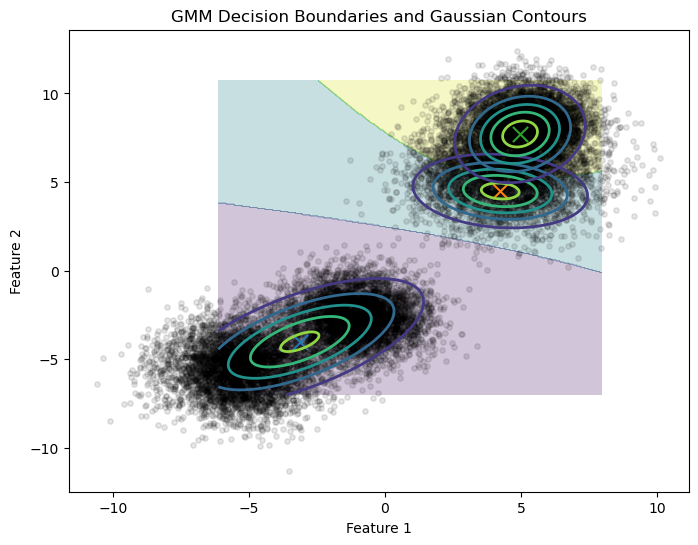

In [44]:
df3 = pd.read_csv(df3_path)

X = np.array(df3.iloc[:,:-1].copy())
y = np.array(df3.iloc[:,-1].copy())

file_name = "3_8_Dec_boundaries.png"
file_path = os.path.join(plot_dir, file_name)

# extract first two dimensions
X2 = X[:, :2]
K = 3
mu, Sigma, pi, _ = run_gmm_em(X2, K, max_iters=100)
plot_gmm_decision_boundaries(X2, mu, Sigma, pi)

### 3.9 SVM with Slack KKT Verification

In [45]:
def train_soft_margin_svm(X, y, C=1.0, max_iter=200):
    n_samples = X.shape[0]
    K = X @ X.T
    H = np.outer(y, y) * K

    def objective(mu):
        return 0.5 * mu @ H @ mu - np.sum(mu)

    def gradient(mu):
        return H @ mu - np.ones(n_samples)

    def constraint(mu):
        return np.dot(mu, y)

    bounds = [(0, C) for _ in range(n_samples)]
    mu0 = np.zeros(n_samples)

    constraints = {'type': 'eq', 'fun': constraint}

    result = minimize(objective,mu0, jac=gradient, method='SLSQP',
                      bounds=bounds, constraints=constraints, options={'maxiter': max_iter, 'ftol': 1e-6, 'disp' : True})

    mu = result.x
    w = np.sum((mu * y)[:, None] * X, axis=0)
    sv = (mu > 1e-5) & (mu < C - 1e-5)

    if np.any(sv):
        b = np.mean(y[sv] - X[sv] @ w)
    else:
        b = 0

    return mu, w, b

In [46]:
def verify_kkt(X, y, mu, w, b,idx_orig, C=1.0):
    tol = 1e-3
    decision = X @ w + b
    margins = y * decision

    inside_margin = None
    on_margin = None
    outside_margin = None

    for i in range(len(mu)):

        if mu[i] > C - tol and margins[i] < 1 - tol:
            inside_margin = (i, mu[i],idx_orig[i])

        elif tol < mu[i] < C - tol and abs(margins[i] - 1) < tol:
            on_margin = (i, mu[i],idx_orig[i])

        elif mu[i] < tol and margins[i] > 1 + tol:
            outside_margin = (i, mu[i],idx_orig[i])

        if inside_margin and on_margin and outside_margin:
            break

    print("\nKKT Verification Results:\n")

    print("Inside Margin: ")
    if inside_margin is not None:
      print(f"(a) Inside Margin: index in subset={inside_margin[0]}, index in original data={inside_margin[2]}, mu={inside_margin[1]:.6f}")

    else:
      print("No points strictly Inside Margin.")


    print("\nOn the Margin:")
    if on_margin is not None:
      print(f"(b) On Margin: index={on_margin[0]}, index in original data={on_margin[2]} , mu={on_margin[1]:.6f}")
    else:
      print("No points strictly on the Margin.")

    print("\nOutside the Margin:")
    if outside_margin is not None:
      print(f"Outside Margin: index={outside_margin[0]}, index in original data={outside_margin[2]}, mu={outside_margin[1]:.6f}")
    else:
      print("No points strictly on the Margin.")

In [47]:
df3 = pd.read_csv(df3_path)

X = np.array(df3.iloc[:,:-1].copy())
y = np.array(df3.iloc[:,-1].copy())

# Filtering
mask = (y == 1) | (y == 2)

X_filtered = X[mask]
y_filtered = y[mask]

subset = 1024
idx = np.random.choice(len(X_filtered), subset, replace=False)

# Taking only the subset of data
X_sub = X[idx]
y_sub = y[idx]

# Convert labels to {-1, +1}
y_filtered = np.where(y_sub == 1, -1, 1)

mu, w, b = train_soft_margin_svm(X_sub, y_filtered, C=1.0)
verify_kkt(X_sub, y_sub, mu, w, b,idx, C=1.0)

Optimization terminated successfully    (Exit mode 0)
            Current function value: -0.0015172987058250844
            Iterations: 5
            Function evaluations: 16
            Gradient evaluations: 5

KKT Verification Results:

Inside Margin: 
No points strictly Inside Margin.

On the Margin:
No points strictly on the Margin.

Outside the Margin:
Outside Margin: index=1019, index in original data=4796, mu=0.000000


### 3.10 Mercer’s Condition

In [51]:
def rbf_kernel_matrix(X, gamma=0.5):
    """
    Compute RBF kernel matrix in a numerically stable vectorized way.
    """
    # Squared norms of each row
    sq_norms = np.sum(X**2, axis=1)
    # Pairwise squared Euclidean distance
    dists = sq_norms[:, None] + sq_norms[None, :] - 2 * (X @ X.T)
    # Numerical safety
    dists = np.maximum(dists, 0)
    K = np.exp(-gamma * dists)
    # Enforce symmetry for numerical stability
    K = (K + K.T) / 2

    return K

In [52]:
def verify_psd(K, tol=1e-10):

    # Use eigvalsh since K is symmetric
    eigenvalues = np.linalg.eigvalsh(K)

    min_eig = np.min(eigenvalues)

    print("Minimum eigenvalue:", min_eig)

    if min_eig >= -tol:
        print("Kernel matrix is Positive Semi-Definite (Mercer's condition satisfied)")
    else:
        print("Kernel matrix is NOT Positive Semi-Definite")
    return eigenvalues

In [53]:
# Load dataset
df3 = pd.read_csv(df3_path)

# Convert to float64 for numerical stability
X = df3.iloc[:, :-1].to_numpy(dtype=np.float64)
y = df3.iloc[:, -1].to_numpy()


# --- Select 1000 sample subset ---
subset_size = 1000
indices = np.random.choice(X.shape[0], subset_size, replace=False)

X_subset = X[indices]

print("Subset shape:", X_subset.shape)

# --- Kernel computation ---
gamma = 0.5
K = rbf_kernel_matrix(X_subset, gamma)

print("Kernel matrix shape:", K.shape)

# --- Eigenvalue analysis ---
eigenvalues = verify_psd(K)

print("First 10 eigenvalues:")
for i in range(10):
  print(eigenvalues[i],end = " ")

Subset shape: (1000, 50)
Kernel matrix shape: (1000, 1000)
Minimum eigenvalue: 0.9999999679311092
Kernel matrix is Positive Semi-Definite (Mercer's condition satisfied)
First 10 eigenvalues:
0.9999999679311092 0.9999999999814234 0.9999999999875787 0.9999999999960785 0.9999999999964458 0.9999999999967404 0.9999999999967951 0.9999999999974947 0.999999999998351 0.9999999999983532 

### 3.11 Hyperparameter Topography

In [54]:
def custom_train_test_split(X, y, train_ratio=0.8, random_state=42):
    np.random.seed(random_state)
    indices = np.random.permutation(len(X))
    split = int(len(X) * train_ratio)

    train_idx = indices[:split]
    val_idx = indices[split:]

    return X[train_idx], X[val_idx], y[train_idx], y[val_idx]


def accuracy(y_true, y_pred):
    return np.mean(y_true == y_pred)


# RBF Kernel
def rbf_kernel(X1, X2, sigma):
    X1 = X1.astype(np.float64)
    X2 = X2.astype(np.float64)

    sq1 = np.sum(X1**2, axis=1)
    sq2 = np.sum(X2**2, axis=1)

    dists = sq1[:,None] + sq2[None,:] - 2 * X1 @ X2.T
    dists = np.maximum(dists,0)

    return np.exp(-dists/(2*sigma**2))

In [55]:
# Binary SVM using CVXOPT
class BinarySVM:
    def __init__(self, C=1.0, sigma=1.0):
        self.C = C
        self.sigma = sigma

        self.mu = None
        self.b = 0

        self.X_train = None
        self.y_train = None


    def fit(self, X, y):
        self.X_train = X
        self.y_train = y

        n = X.shape[0]
        K = rbf_kernel(X, X, self.sigma)
        H = np.outer(y,y) * K

        P = matrix(H.astype(np.double))
        q = matrix(-np.ones(n))

        G = matrix(np.vstack((-np.eye(n), np.eye(n))).astype(np.double))
        h = matrix(np.hstack((np.zeros(n), np.ones(n)*self.C)).astype(np.double))

        A = matrix(y.reshape(1,-1).astype(np.double))
        b = matrix(np.zeros(1))

        solvers.options['show_progress'] = False
        solution = solvers.qp(P,q,G,h,A,b)
        mu = np.array(solution['x']).flatten()

        tol = 1e-5

        sv = np.where(mu > tol)[0]
        margin_sv = np.where((mu > tol) & (mu < self.C - tol))[0]

        if len(margin_sv) > 0:
            sv_for_bias = margin_sv
        else:
            sv_for_bias = sv

        b_vals = []

        for i in sv_for_bias:
            decision = np.sum(mu * y * K[:,i])
            b_vals.append(y[i] - decision)

        self.mu = mu
        self.b = np.mean(b_vals)


    def decision_function(self, X_test):
        K = rbf_kernel(self.X_train, X_test, self.sigma)
        return (self.mu * self.y_train) @ K + self.b



# Multi-Class One-vs-Rest SVM
class MultiClassSVM:
    def __init__(self, C=1.0, sigma=1.0):
        self.C = C
        self.sigma = sigma

        self.models = []
        self.classes = None


    def fit(self, X, y):
        self.classes = np.unique(y)
        self.models = []
        for c in self.classes:

            y_binary = np.where(y == c, 1, -1)
            model = BinarySVM(C=self.C, sigma=self.sigma)
            model.fit(X, y_binary)
            self.models.append(model)


    def predict(self, X):
        scores = []
        for model in self.models:
            scores.append(model.decision_function(X))

        scores = np.vstack(scores)
        idx = np.argmax(scores, axis=0)
        return self.classes[idx]

In [56]:
# Grid Search
def grid_search_rbf(X_train, y_train, X_val, y_val):
    C_values = [0.1,1,10,100]
    sigma_values = [0.001,0.01,0.1,1,10]

    train_acc = np.zeros((len(C_values),len(sigma_values)))
    val_acc = np.zeros((len(C_values),len(sigma_values)))

    for i,C in enumerate(C_values):
        for j,sigma in enumerate(sigma_values):
            clf = MultiClassSVM(C=C, sigma=sigma)
            clf.fit(X_train,y_train)

            pred_train = clf.predict(X_train)
            pred_val = clf.predict(X_val)

            train_acc[i,j] = accuracy(y_train,pred_train)
            val_acc[i,j] = accuracy(y_val,pred_val)
            print(f"C={C}, sigma={sigma}, train={train_acc[i,j]:.3f}, val={val_acc[i,j]:.3f}")
    return C_values, sigma_values, train_acc, val_acc



# Detect Overfitting
def detect_overfitting(C_values, sigma_values, train_acc, val_acc):
    gap = train_acc - val_acc
    idx = np.unravel_index(np.argmax(gap), gap.shape)

    print("\nMost severe overfitting at:")
    print("C =", C_values[idx[0]])
    print("sigma =", sigma_values[idx[1]])
    print("train acc =", train_acc[idx])
    print("val acc =", val_acc[idx])

In [57]:
# Heatmap Plot
def plot_heatmap(C_values, sigma_values, val_acc, save_path = None):
    plt.figure(figsize=(7,5))

    cax = plt.imshow(val_acc, cmap='viridis', interpolation='nearest', aspect='auto')

    plt.xticks(np.arange(len(sigma_values)), sigma_values)
    plt.yticks(np.arange(len(C_values)), C_values)

    for i in range(len(C_values)):
        for j in range(len(sigma_values)):

            color = "black" if val_acc[i,j] > 0.6 else "white"

            plt.text(j,i,f"{val_acc[i,j]:.3f}",ha="center",va="center",color=color)

    plt.colorbar(cax,label="Validation Accuracy")

    plt.title("RBF SVM Validation Accuracy Heatmap")
    plt.xlabel("Sigma (σ)")
    plt.ylabel("Regularization Parameter (C)")

    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi = 300)  
    plt.show()

Training samples: 409
Validation samples: 103
C=0.1, sigma=0.001, train=0.521, val=0.447
C=0.1, sigma=0.01, train=0.521, val=0.447
C=0.1, sigma=0.1, train=0.521, val=0.447
C=0.1, sigma=1, train=0.858, val=0.621
C=0.1, sigma=10, train=1.000, val=1.000
C=1, sigma=0.001, train=1.000, val=0.447
C=1, sigma=0.01, train=1.000, val=0.447
C=1, sigma=0.1, train=1.000, val=0.447
C=1, sigma=1, train=1.000, val=1.000
C=1, sigma=10, train=1.000, val=1.000
C=10, sigma=0.001, train=1.000, val=0.447
C=10, sigma=0.01, train=1.000, val=0.447
C=10, sigma=0.1, train=1.000, val=0.447
C=10, sigma=1, train=1.000, val=1.000
C=10, sigma=10, train=1.000, val=1.000
C=100, sigma=0.001, train=1.000, val=0.447
C=100, sigma=0.01, train=1.000, val=0.447
C=100, sigma=0.1, train=1.000, val=0.447
C=100, sigma=1, train=1.000, val=1.000
C=100, sigma=10, train=1.000, val=1.000


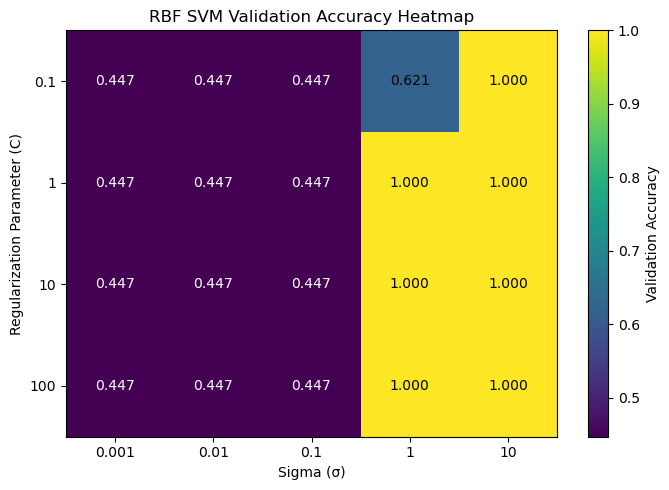


Most severe overfitting at:
C = 1
sigma = 0.001
train acc = 1.0
val acc = 0.44660194174757284


In [59]:
# Load Dataset
df3 = pd.read_csv(df3_path)

X = df3.iloc[:,:-1].to_numpy()
y = df3.iloc[:,-1].to_numpy()

classes = np.unique(y)

# Subsample (for solver stability)
subset = 512
if X.shape[0] > subset:
    idx = np.random.choice(X.shape[0], subset, replace=False)

    X = X[idx]
    y = y[idx]


# Train / Validation Split
X_train, X_val, y_train, y_val = custom_train_test_split(X,y)

print("Training samples:",len(X_train))
print("Validation samples:",len(X_val))


# Feature Scaling
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)

file_name = "3_11_heatmap.png"
file_path = os.path.join(plot_dir, file_name)

# Run Grid Search
C_values, sigma_values, train_acc, val_acc = grid_search_rbf(X_train, y_train, X_val, y_val)
plot_heatmap(C_values, sigma_values, val_acc, file_path) # Plot Heatmap
detect_overfitting(C_values, sigma_values, train_acc, val_acc) # Detect Overfitting

In [86]:
print(classes)

[0 1 2]


In [213]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize

# ==========================================
# 1. Custom Core Functions (Replacing sklearn)
# ==========================================
def custom_train_test_split(X, y, train_ratio=0.75, random_state=42):
    """Pure NumPy implementation of train/test split."""
    np.random.seed(random_state)
    indices = np.random.permutation(len(X))
    split_idx = int(len(X) * train_ratio)
    
    train_idx, val_idx = indices[:split_idx], indices[split_idx:]
    return X[train_idx], X[val_idx], y[train_idx], y[val_idx]

def accuracy(y_true, y_pred):
    """Calculates classification accuracy."""
    return np.mean(y_true == y_pred)

def rbf_kernel(X1, X2, sigma):
    """Computes the RBF kernel matrix between two sets of vectors."""
    # Efficient pairwise squared Euclidean distance
    sq_dists = np.sum(X1**2, axis=1).reshape(-1, 1) + np.sum(X2**2, axis=1) - 2 * np.dot(X1, X2.T)
    return np.exp(-sq_dists / (2 * sigma**2))

# ==========================================
# 2. Custom Binary SVM & Multi-Class Wrapper
# ==========================================
class CustomBinarySVM:
    def __init__(self, C=1.0, sigma=1.0):
        self.C = C
        self.sigma = sigma
        self.alphas = None
        self.b = 0
        self.X_train = None
        self.y_train = None

    def fit(self, X, y):
        self.X_train = X
        self.y_train = y
        N = len(y)
        
        # Precompute kernel matrix and Hessian
        K = rbf_kernel(X, X, self.sigma)
        Y = np.outer(y, y)
        H = Y * K
        
        # Dual formulation objective: Min 0.5 * a^T H a - sum(a)
        def objective(a):
            return 0.5 * np.dot(a, np.dot(H, a)) - np.sum(a)
            
        def jacobian(a):
            return np.dot(H, a) - np.ones_like(a)

        constraints = ({'type': 'eq', 'fun': lambda a: np.dot(a, y), 'jac': lambda a: y})
        bounds = [(0, self.C) for _ in range(N)]
        a0 = np.zeros(N)

        res = minimize(objective, a0, method='SLSQP', jac=jacobian, 
                       bounds=bounds, constraints=constraints, options={'ftol': 1e-4, 'maxiter': 5})  # iters
        
        self.alphas = res.x
        
        # Calculate bias term (b) using support vectors (0 < alpha < C)
        sv_idx = np.where((self.alphas > 1e-5) & (self.alphas < self.C - 1e-5))[0]
        if len(sv_idx) > 0:
            s_idx = sv_idx[0]
            self.b = y[s_idx] - np.sum(self.alphas * self.y_train * K[:, s_idx])
        else:
            self.b = 0.0 # Fallback if no free support vectors are found

    def decision_function(self, X_test):
        # f(x) = sum(alpha_i * y_i * K(x_i, x)) + b
        K_test = rbf_kernel(self.X_train, X_test, self.sigma)
        return np.dot((self.alphas * self.y_train), K_test) + self.b

class CustomMultiClassSVM:
    """One-vs-Rest (OvR) Wrapper for Multi-Class Classification"""
    def __init__(self, C=1.0, sigma=1.0):
        self.C = C
        self.sigma = sigma
        self.models = []
        self.classes = []

    def fit(self, X, y):
        self.classes = np.unique(y)
        for c in self.classes:
            # Map target class to +1, all others to -1
            y_binary = np.where(y == c, 1, -1)
            model = CustomBinarySVM(C=self.C, sigma=self.sigma)
            model.fit(X, y_binary)
            self.models.append(model)

    def predict(self, X):
        # Get decision function scores from all 3 binary models
        scores = np.zeros((len(X), len(self.classes)))
        for i, model in enumerate(self.models):
            scores[:, i] = model.decision_function(X)
        # Choose the class with the highest confidence score
        return self.classes[np.argmax(scores, axis=1)]


# ==========================================
# 3. Data Prep & Execution
# ==========================================
print("--- 3.11 Hyperparameter Topography (Pure NumPy/SciPy) ---")
# Subsample heavily so the QP solver doesn't freeze
N_subset = 200 
np.random.seed(42)
idx = np.random.choice(len(X), N_subset, replace=False)
X_sub, y_sub = X[idx], y[idx].flatten()

X_train, X_val, y_train, y_val = custom_train_test_split(X_sub, y_sub, train_ratio=0.75)
print(f"Training on {len(X_train)} samples, Validating on {len(X_val)} samples.")

C_values = [0.1, 1, 10, 100]
sigma_values = [0.001, 0.01, 0.1, 1, 10]

val_acc_matrix = np.zeros((len(C_values), len(sigma_values)))
overfit_gap_matrix = np.zeros((len(C_values), len(sigma_values)))

print(f"Executing Grid Search (Total fits: {len(C_values) * len(sigma_values) * 3})...")

for i, C in enumerate(C_values):
    for j, sigma in enumerate(sigma_values):
        
        clf = CustomMultiClassSVM(C=C, sigma=sigma)
        clf.fit(X_train, y_train)
        
        train_preds = clf.predict(X_train)
        val_preds = clf.predict(X_val)
        
        train_acc = accuracy(y_train, train_preds)
        val_acc = accuracy(y_val, val_preds)
        
        val_acc_matrix[i, j] = val_acc
        overfit_gap_matrix[i, j] = train_acc - val_acc

print("Optimization complete.\n")

# ==========================================
# 4. Identify Severe Overfitting & Plot
# ==========================================
max_overfit_idx = np.unravel_index(np.argmax(overfit_gap_matrix), overfit_gap_matrix.shape)

print(f"[Deliverable] Most Severe Overfitting Coordinate:")
print(f"-> C = {C_values[max_overfit_idx[0]]}, sigma = {sigma_values[max_overfit_idx[1]]}")
print(f"-> Overfitting Gap: {overfit_gap_matrix[max_overfit_idx] * 100:.2f}%\n")

plt.figure(figsize=(10, 7))
# Standard matplotlib alternative to seaborn heatmap
cax = plt.imshow(val_acc_matrix, cmap='viridis', interpolation='nearest', aspect='auto')

plt.xticks(np.arange(len(sigma_values)), sigma_values)
plt.yticks(np.arange(len(C_values)), C_values)

# Annotate cells manually
for i in range(len(C_values)):
    for j in range(len(sigma_values)):
        color = "black" if val_acc_matrix[i, j] > 0.6 else "white"
        plt.text(j, i, f"{val_acc_matrix[i, j]:.3f}", ha="center", va="center", color=color)

# Highlight worst overfitting
plt.gca().add_patch(plt.Rectangle((max_overfit_idx[1]-0.5, max_overfit_idx[0]-0.5), 1, 1, fill=False, edgecolor='red', lw=4))

plt.colorbar(cax, label="Validation Accuracy")
plt.title("3.11: Custom RBF SVM Validation Accuracy (No Sklearn)")
plt.xlabel("Sigma ($\sigma$)")
plt.ylabel("Regularization Parameter ($C$)")
plt.tight_layout()
plt.show()

## Phase 4: Unscaled Electronic Health Records (Dataset 4)

### 4.12 Multiclass Extension & Scaling

In [60]:
class StandardScaler:
    def __init__(self):
        self.mean_ = None
        self.std_dev_ = None

    def fit(self, X):
        X = np.asarray(X)
        if X.ndim != 2:
            raise ValueError("Input must be a 2D array")

        self.mean_ = np.mean(X, axis=0)
        std = np.std(X, axis=0)
        # avoid division by zero
        self.std_dev_ = np.where(std == 0, 1.0, std)
        return self

    def transform(self, X):
        if self.mean_ is None or self.std_dev_ is None:
            raise RuntimeError("Scaler must be fitted before transform")
        X = np.asarray(X)
        if X.shape[1] != self.mean_.shape[0]:
            raise ValueError("Mismatch between fit and transform dimensions")

        return (X - self.mean_) / self.std_dev_

    def fit_transform(self, X):
        self.fit(X)
        return self.transform(X)

In [62]:
def sigmoid(z):
    z = np.clip(z, -500, 500)
    return 1 / (1 + np.exp(-z))

def cross_entropy_loss(y,p):
    return -np.mean(y * np.log(p + 1e-12) + (1 - y) * np.log(1 - p + 1e-12))

def train_logistic(X, y, lr=0.01, max_iter=1000, tol=1e-4):
    y = y.reshape(-1)
    n, d = X.shape
    theta = np.zeros(d)
    prev_loss = float("inf")


    for i in range(max_iter):
        z = X @ theta
        p = sigmoid(z)
        gradient = X.T @ (p - y) / n
        theta = theta - lr * gradient

        loss = cross_entropy_loss(y,p)

        if abs(prev_loss - loss) < tol: # Early Stopping
            return theta, i + 1
        prev_loss = loss
        
    return theta, max_iter


def logistic_ovr(X, y, lr=0.01, max_iter=1000, tol=1e-4):
    y = y.reshape(-1)
    classes = np.unique(y)
    weights = []
    iterations = []

    for class_ in classes:

        y_binary = (y == class_).astype(int)

        theta, iters = train_logistic( X, y_binary, lr=lr, max_iter=max_iter, tol=tol)
        weights.append(theta)
        iterations.append(iters)

    return np.array(weights), iterations

In [63]:
# Reading Dataset
df4 = pd.read_csv(df4_path)
X = np.array(df4.iloc[:,:-1].copy())
y = np.array(df4.iloc[:,-1].copy())

# Fitting the Standard Scaler
X_std = X.copy()
std_scaler = StandardScaler()
std_scaler.fit(X_std)
X_std = std_scaler.transform(X_std)

# Adding a Bias Column
ones_col = np.ones((X.shape[0],1))
X = np.hstack((X, ones_col),dtype = np.float32)
X_std = np.hstack((X_std, ones_col),dtype = np.float32)

In [64]:
weights_orig, iter_orig = logistic_ovr( X, y,lr=0.1,max_iter=1000)
weights_scaled, iter_scaled = logistic_ovr(X_std, y,lr=0.1,max_iter=1000)

print("Iterations (Raw):", iter_orig)
print("Iterations (Scaled):", iter_scaled)

Iterations (Raw): [1000, 1000]
Iterations (Scaled): [257, 257]


### 4.13 Vectorization Benchmarking

In [65]:
def KNN_brute(X, y, k = 5):
    predictions = []
    for i, data in enumerate(X):
        dist = np.zeros(X.shape[0])
        for idx,neighbor in enumerate(X):
            diff = data-neighbor
            euclid_dist = np.dot(diff,diff)
            dist[idx] = euclid_dist
        candidates = np.argpartition(dist, k+1)[:(k+1)] # Ignore the distance with self. That will always be zero.
        nearest_neighbors = candidates[candidates != i][:k]
        
        y_classes = y[nearest_neighbors]
        unique_values, counts = np.unique(y_classes, return_counts=True) # Ties broken arbitrarily
        y_pred = unique_values[np.argmax(counts)]
        predictions.append(y_pred)
        
    return np.array(predictions)


def KNN_vectorized(X, y, k=5):
    N = X.shape[0]

    # Compute pairwise squared distance matrix
    cross_prod = X @ X.T
    norms = np.sum(X**2, axis=1, keepdims=True)
    distances = norms + norms.T - 2 * cross_prod
    distances = np.maximum(distances, 0) # Numerical stability

    # Ignore self-distance
    np.fill_diagonal(distances, np.inf)
    
    neighbors = np.argpartition(distances, k, axis=1)[:, :k] # Get indices of k nearest neighbors
    neighbor_labels = y[neighbors]

    predictions = np.zeros(N, dtype=y.dtype)

    # Majority vote
    for i in range(N):
        values, counts = np.unique(neighbor_labels[i], return_counts=True)
        predictions[i] = values[np.argmax(counts)]

    return predictions

In [66]:
def benchmark_knn(X, y, k=5, sample_size=2000, seed=42):
    # Random subset of dataset
    indices = np.random.choice(X.shape[0], sample_size, replace=False)
    X_sample = X[indices]
    y_sample = y[indices]

    print(f"Dataset sample size: {sample_size}")
    print(f"k = {k}\n")

    # ----- Brute Force KNN -----
    start = time.perf_counter()
    preds_brute = KNN_brute(X_sample, y_sample, k)
    brute_time = time.perf_counter() - start

    # ----- Vectorized KNN -----
    start = time.perf_counter()
    preds_vec = KNN_vectorized(X_sample, y_sample, k)
    vec_time = time.perf_counter() - start

    # Consistency check
    same_predictions = np.all(preds_brute == preds_vec)

    print("Results")
    print("-------")
    print(f"Brute Force Time:      {brute_time:.4f} seconds")
    print(f"Vectorized Time:       {vec_time:.4f} seconds")
    print(f"Speedup Factor:        {brute_time / vec_time:.2f}x")
    print(f"Predictions Identical: {same_predictions}")

In [67]:
# Reading Dataset
df4 = pd.read_csv(df4_path)
X = np.array(df4.iloc[:,:-1].copy())
y = np.array(df4.iloc[:,-1].copy())

# Adding a Bias Column
ones_col = np.ones((X.shape[0],1))
X = np.hstack((X, ones_col),dtype = np.float32)

In [68]:
benchmark_knn(X, y, k=5, sample_size=2000)

Dataset sample size: 2000
k = 5

Results
-------
Brute Force Time:      2.1745 seconds
Vectorized Time:       0.0448 seconds
Speedup Factor:        48.49x
Predictions Identical: True


### 4.14 The Curse of Scale

In [69]:
def benchmark_knn_scaling(X, y, k=5):
    
    # Fitting the Standard Scaler
    X_std = X.copy()
    std_scaler = StandardScaler()
    std_scaler.fit(X_std)
    X_std = std_scaler.transform(X_std)

    # Adding a Bias Column
    ones_col = np.ones((X.shape[0],1))
    X = np.hstack((X, ones_col),dtype = np.float32)
    X_std = np.hstack((X_std, ones_col),dtype = np.float32)

    print(f"Dataset size: {X.shape}")
    print(f"k = {k}\n")

    # ----- Original Data -----
    preds_orig = KNN_vectorized(X, y, k)
    pred_acc_orig = np.sum(preds_orig == y)/y.shape[0]
    
    # ----- Scaled Data -----
    preds_scaled = KNN_vectorized(X_std, y, k)
    pred_acc_scaled = np.sum(preds_scaled == y)/y.shape[0]

    # Consistency check
    same_predictions = np.all(preds_orig == preds_scaled)

    print("Results")
    print("-------")
    print(f"Original Data:      {pred_acc_orig:.4f}")
    print(f"Scaled Data:       {pred_acc_scaled:.4f}")
    print(f"Absolute Difference:        {np.abs(pred_acc_orig-pred_acc_scaled):.4f}")
    print(f"Predictions Identical: {same_predictions}")

In [70]:
# Reading Dataset
df4 = pd.read_csv(df4_path)
X = np.array(df4.iloc[:,:-1].copy())
y = np.array(df4.iloc[:,-1].copy())

# Bias added inside the function
benchmark_knn_scaling(X,y, k = 3)

Dataset size: (15000, 65)
k = 3

Results
-------
Original Data:      0.8801
Scaled Data:       0.9217
Absolute Difference:        0.0415
Predictions Identical: False


### 4.15 Bayes Optimal & Underflow

In [71]:
def gaussian_pdf(X, mean, var):
    coeff = 1.0 / np.sqrt(2 * np.pi * var)
    exponent = np.exp(-((X - mean) ** 2) / (2 * var))
    return coeff * exponent


class NaiveBayes():
    def __init__(self):
        self.index_to_label = {}
        self.class_means = {}
        self.class_var = {}
        self.class_prior = None

    def _gaussian_logpdf(self,X, mean, var):
        term1 = -0.5 * np.log(2 * np.pi * var)
        term2 = -((X - mean) ** 2) / (2 * var)
        return term1 + term2

    def fit(self,X,y):
        y = y.reshape(-1)
        classes, counts = np.unique(y, return_counts=True)
        self.class_prior = np.log(counts/y.shape[0])

        class_index = 0
        for class_ in classes:
            self.index_to_label[class_index] = class_
            class_index+=1
            
        for class_ in self.index_to_label:
            label = self.index_to_label[class_]
            X_filtered = X[y == label]
            mean = np.mean(X_filtered, axis = 0)
            var = np.var(X_filtered, axis = 0) + 1e-6
            
            self.class_means[class_] = mean
            self.class_var[class_] = var
            

    def predict(self, X):
        # This stores the posterior for each data point for each class
        num_classes = len(self.index_to_label)
        posterior = np.zeros((num_classes, X.shape[0])) 
        
        for class_index in self.index_to_label:
            mean = self.class_means[class_index]
            var = self.class_var[class_index]
            # Setting each Row of the matrix. Each column denotes a class.
            posterior[class_index] = np.sum(self._gaussian_logpdf(X,mean,var),axis= 1) + self.class_prior[class_index]
            
        predictions = np.argmax(posterior,axis = 0)
        prediction_labels = [self.index_to_label[x] for x in predictions]
        return np.array(prediction_labels, dtype = np.int32)

In [72]:
def naive_bayes_raw_probability(X, mean, var, prior):
    probs = gaussian_pdf(X, mean, var)
    joint_prob = np.prod(probs, axis=1)
    joint_prob = joint_prob * prior
    
    return joint_prob.astype(np.float32)

def find_underflow_dimension(X, y):

    classes = np.unique(y)
    class_ = classes[0]
    X_class = X[y == class_]

    mean = np.mean(X_class, axis=0)
    var = np.var(X_class, axis=0) + 1e-6

    prior = np.sum(y == class_) / len(y)
    D_max = X.shape[1]

    for D in range(1, D_max+1):

        X_sub = X[:, :D].astype(np.float32)
        mean_sub = mean[:D].astype(np.float32)
        var_sub = var[:D].astype(np.float32)

        joint_prob = naive_bayes_raw_probability(X_sub, mean_sub, var_sub, prior)

        if np.any(joint_prob == 0.0):
            print(f"Underflow occurs at feature dimension D = {D}")
            return D

    print("No underflow detected within dataset dimension.")

In [73]:
# Reading Dataset
df4 = pd.read_csv(df4_path)
X = np.array(df4.iloc[:,:-1].copy())
y = np.array(df4.iloc[:,-1].copy())

In [74]:
naive_bayes = NaiveBayes()
naive_bayes.fit(X,y)
predictions = naive_bayes.predict(X)

In [75]:
find_underflow_dimension(X,y)

Underflow occurs at feature dimension D = 28


28

## Phase 5: Bias-Variance Decomposition

### 5.16 Empirical Bias-Variance via Bootstrapping (Dataset 1)

In [87]:
def least_squares_grad(X,y,theta):
    n = X.shape[0]
    resid = (X @ theta) - y
    grad_ = (2/n) * (X.T @ resid)
    return grad_

# Gradient Function for L2 Regularization
def grad_l2(X,y,theta, lambda_):
    n = X.shape[0]
    resid = (X @ theta) - y
    
    theta_ = theta.copy()
    theta_[-1] = 0 # Bias should not be updated
    
    grad_ = (2/n) * (X.T @ resid) + 2 * lambda_ * theta_
    return grad_

def lin_reg_batch_gd(X,y,grad,lambda_ = 1e-2, epsilon = 1e-6, lr = 0.01, max_iter = 500):
    y = y.reshape(-1)
    theta = np.random.normal(size = X.shape[1])
    # theta = np.zeros(X.shape[1])
    iter_ = 0
    while iter_ < max_iter:
        grad_calc = grad(X,y, theta, lambda_)
        if np.linalg.norm(grad_calc) < epsilon:
            break
        theta = theta - lr * grad_calc
        iter_+=1
    return theta

def ols_closed(X,y, lambda_ = 0):
    y = y.reshape(-1)
    X = np.array(X)
    y = np.array(y)

    lhs = (X.T @ X + lambda_ * np.eye(X.shape[1]))
    rhs = (X.T @ y)
    theta = np.linalg.inv(lhs) @ rhs

    return theta

def polynomial_transform(X, degree = 15):
    feat = X[:,:-1].copy()
    X_transformed = np.zeros((feat.shape[0], degree))
    for d in range(degree):
        X_t = feat ** d
        X_transformed[:,d] = X_t.reshape(-1)

    ones_col = np.ones((X.shape[0],1))
    X_transformed = np.hstack((X_transformed, ones_col),dtype = np.float32)
        
    return X_transformed

In [88]:
def bootstrapped_lr(X, y, transform = None, degree = 15, num_samples = 100, lambda_ = 0):
    
    num_data = X.shape[0]
    parameters = []
    
    if transform:
        X = polynomial_transform(X,degree)
    
    for _ in range(num_samples):
        bootstrap_indices = np.random.choice(a=np.arange(num_data), size=num_data, replace=True)
        X_bootstrapped = X[bootstrap_indices]
        y_bootstrapped = y[bootstrap_indices]
        
        params = ols_closed(X_bootstrapped,y_bootstrapped, lambda_ = lambda_)
        parameters.append(params)
    
    return np.array(parameters)


def compute_bias_variance(X_train, y_train, X_test, y_test, lambda_ = 0, degree=1, num_bootstrap=100):

    # Train bootstrapped models
    parameters = bootstrapped_lr( X_train, y_train,
        transform=(polynomial_transform if degree > 1 else None),
        degree=degree, num_samples=num_bootstrap, lambda_ = lambda_)

    # Apply polynomial transform to test data if required
    if degree > 1:
        X_test = polynomial_transform(X_test, degree)

    # Predictions from each bootstrap model
    preds = []
    for theta in parameters:
        preds.append(X_test @ theta)

    preds = np.array(preds)   # shape (B, N_test)
    mean_pred = np.mean(preds, axis=0)  # Mean prediction across bootstrap models
    bias_sq = np.mean((mean_pred - y_test) ** 2)  # Empirical squared bias
    variance = np.mean(np.var(preds, axis=0))  # Empirical variance

    return bias_sq, variance

In [89]:
# Reading Dataset
df1 = pd.read_csv(df1_path)

X = np.array(df1.iloc[:,:-1].copy())
y = np.array(df1.iloc[:,-1].copy())

# Fitting the Standard Scaler
X_std = X.copy()
std_scaler = StandardScaler()
std_scaler.fit(X_std)
X_std = std_scaler.transform(X_std)

# Adding a Bias Column
ones_col = np.ones((X.shape[0],1))
X = np.hstack((X, ones_col),dtype = np.float32)
X_std = np.hstack((X_std, ones_col),dtype = np.float32)

In [91]:
perm = np.random.permutation(len(X))
split = int(0.8 * len(X))

X_train, X_test = X[perm[:split]], X[perm[split:]]
y_train, y_test = y[perm[:split]], y[perm[split:]]

# Degree 1
bias_d1, var_d1 = compute_bias_variance(X_train, y_train, X_test, y_test, degree=1)

# Degree 15
bias_d15, var_d15 = compute_bias_variance(X_train, y_train, X_test, y_test, degree=15, lambda_ = 1e-3)

print("Results")
print("-------")
print(f"Degree 1  -> Bias^2: {bias_d1:.6f}, Variance: {var_d1:.6f}")
print(f"Degree 15 -> Bias^2: {bias_d15:.6f}, Variance: {var_d15:.6f}")

Results
-------
Degree 1  -> Bias^2: 2.715304, Variance: 0.001063
Degree 15 -> Bias^2: 2.711590, Variance: 0.126757


### 5.17 Frequentist vs. Bayesian Uncertainty (Dataset 1)

In [30]:
# Frequentist Bootstrap Estimation
def bootstrap_slope_variance(X_b, y, B=100, seed=42):
    np.random.seed(seed)

    y_flat = y.flatten()
    N = X_b.shape[0]

    bootstrapped_slopes = np.zeros(B)

    for b in range(B):

        indices = np.random.choice(N, size=N, replace=True)

        X_boot = X_b[indices]
        y_boot = y_flat[indices]

        theta_hat, _, _, _ = np.linalg.lstsq(X_boot, y_boot, rcond=None)

        bootstrapped_slopes[b] = theta_hat[0]   # slope

    freq_mean = np.mean(bootstrapped_slopes)
    freq_variance = np.var(bootstrapped_slopes, ddof=1)

    return bootstrapped_slopes, freq_mean, freq_variance


# Bayesian Posterior Computation
def compute_bayesian_posterior(X_b, y, alpha=1.0):
    y_flat = y.flatten()
    N = X_b.shape[0]

    theta_ols, residuals, _, _ = np.linalg.lstsq(X_b, y_flat, rcond=None)
    print(residuals[0])
    print(X_b.shape)
    
    if len(residuals) > 0:
        noise_variance = residuals[0] / (N - X_b.shape[1])
    else:
        noise_variance = np.var(y_flat - X_b.dot(theta_ols))

    beta = 1.0 / noise_variance

    I = np.eye(X_b.shape[1])

    posterior_cov = np.linalg.inv(alpha * I + beta * X_b.T @ X_b)

    posterior_mean = posterior_cov @ (beta * X_b.T @ y_flat)
    bayes_mean = posterior_mean[0]
    bayes_variance = posterior_cov[0,0]
    return bayes_mean, bayes_variance, posterior_mean, posterior_cov

In [83]:
# Plot Distributions
def plot_uncertainty_distributions(freq_mean, freq_variance, bayes_mean, bayes_variance, file_path=None):

    plt.figure(figsize=(10, 6))

    x_axis = np.linspace(
        min(freq_mean, bayes_mean) - 4 * np.sqrt(max(freq_variance, bayes_variance)),
        max(freq_mean, bayes_mean) + 4 * np.sqrt(max(freq_variance, bayes_variance)),
        1000
    )

    # Frequentist sampling distribution
    freq_pdf = norm.pdf(x_axis, freq_mean, np.sqrt(freq_variance))

    plt.plot(
        x_axis,
        freq_pdf,
        color="blue",
        linewidth=2,
        label=f"Frequentist Sampling Dist\nVar: {freq_variance:.2e}"
    )

    plt.fill_between(x_axis, freq_pdf, color="blue", alpha=0.2)

    # Bayesian posterior
    bayes_pdf = norm.pdf(x_axis, bayes_mean, np.sqrt(bayes_variance))

    plt.plot(
        x_axis,
        bayes_pdf,
        color="green",
        linestyle="--",
        linewidth=2,
        label=f"Bayesian Posterior Dist\nVar: {bayes_variance:.2e}"
    )

    plt.fill_between(x_axis, bayes_pdf, color="green", alpha=0.2)

    plt.title("Frequentist vs Bayesian Uncertainty of Slope Parameter")
    plt.xlabel("Slope Value ($\\theta_1$)")
    plt.ylabel("Density")

    plt.legend()
    plt.tight_layout()

    if file_path is not None:
        plt.savefig(file_path, dpi=300)

    plt.show()

In [23]:
# Data Loading
df = pd.read_csv(df1_path)

X = np.array(df.iloc[:, :-1].copy())
y = np.array(df.iloc[:, -1].copy())

ones_col = np.ones((X.shape[0], 1))
X_b = np.hstack((X, ones_col)).astype(np.float32)

In [36]:
B=100 
alpha=1.0


# Bayesian posterior
print("2. Computing Bayesian Posterior Variance...")
bayes_mean, bayes_variance,posterior_mean, posterior_cov = compute_bayesian_posterior(X_b, y, alpha)
posterior_cov

2. Computing Bayesian Posterior Variance...
11688.762880552655
(5000, 2)


array([[1.39419975e-05, 8.82957885e-07],
       [8.82957885e-07, 4.67576480e-04]])

1. Computing Frequentist Variance via Bootstrapping...
2. Computing Bayesian Posterior Variance...

[Parameter: Linear Slope]
Frequentist Mean (Bootstrap): 4.192659
Frequentist Variance:         1.655776e-05

Bayesian MAP Estimate:        4.192841
Bayesian Posterior Variance:  1.394200e-05



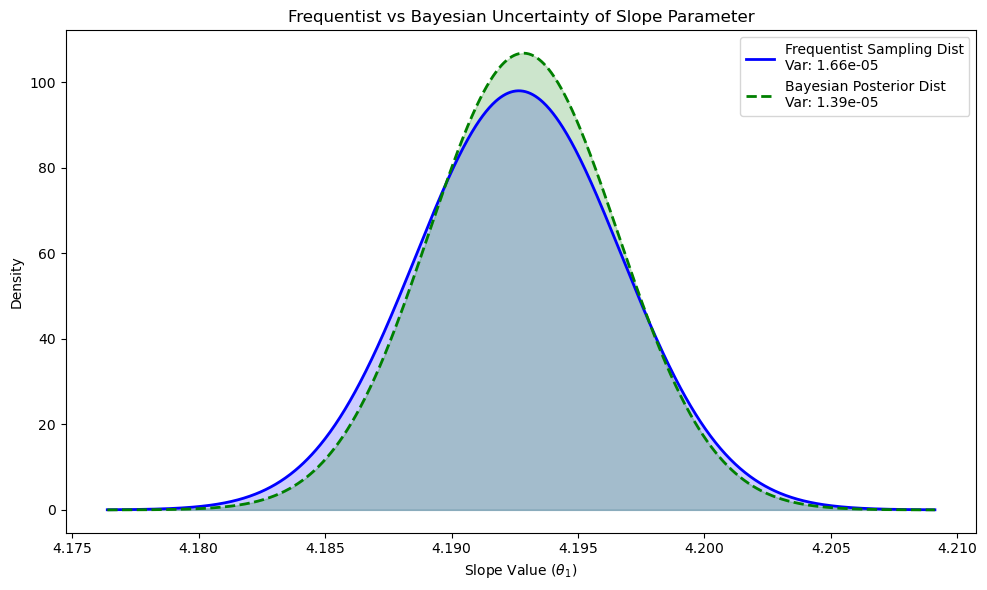

In [85]:
B=100 
alpha=1.0

# Frequentist bootstrap
print("1. Computing Frequentist Variance via Bootstrapping...")
slopes, freq_mean, freq_variance = bootstrap_slope_variance(X_b, y, B)

# Bayesian posterior
print("2. Computing Bayesian Posterior Variance...")
bayes_mean, bayes_variance, _, _ = compute_bayesian_posterior(X_b, y, alpha)

# Print results
print("\n[Parameter: Linear Slope]")
print(f"Frequentist Mean (Bootstrap): {freq_mean:.6f}")
print(f"Frequentist Variance:         {freq_variance:.6e}\n")

print(f"Bayesian MAP Estimate:        {bayes_mean:.6f}")
print(f"Bayesian Posterior Variance:  {bayes_variance:.6e}\n")


# Plot
file_name = "5_17_distributions.png"
file_path = os.path.join(plot_dir, file_name)

plot_uncertainty_distributions( freq_mean, freq_variance, bayes_mean,
    bayes_variance, file_path=file_path)